In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

In [2]:
import importlib
import visualizer
import evaluation
import config
import topic_labeling

importlib.reload(topic_labeling)
importlib.reload(config)
importlib.reload(visualizer)
importlib.reload(evaluation)

<module 'evaluation' from 'd:\\proposal\\thiese\\code\\Persian-Topic-Modeling\\src\\evaluation.py'>

In [3]:
import pandas as pd
import numpy as np
from IPython.display import display , Markdown
import matplotlib.pyplot as plt
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import plotly.io as pio
from umap import UMAP
from hdbscan import HDBSCAN
from pathlib import Path
import time
import stopwordsiso as stopwords
from evaluation import TopicEvaluator
from config import(
    RAW_DATA_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    EMBEDDING_MODEL_NAME,
    N_NEIGHBORS,
    N_COMPONENTS,
    MIN_DIST,
    UMAP_METRIC,
    RANDOM_STATE,
    MIN_CLUSTER_SIZE,
    MIN_SAMPLES,
    CLUSTER_SELECTION_METHOD,
    PREDICTION_DATA,
    COHERENCE_SIZE_SAMPLE,
    NGRAM_RANGE,
    CALCULATE_PROBABILITIES,
    VERBOSE,
    LANGUAGE,
    BATCH_SIZE,
    RESULTS_DIR,
    PROCESSED_DATA_DIR,
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    MAX_LENGTH
)
from preprocessing import clean_text, persian_stopwords
from statistic import DatasetStatistics , TopicStatistics
from visualizer import DatasetVisualizer , TopicVisualizer
from evaluation import TopicEvaluator
from topic_labeling import TopicLabelGenerator


c:\Users\maedeh\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def show_table( table_name):
    """
    Display a generated statistics table.
    """
    table = pd.read_csv(
        TABLES_DIR / f"{table_name}.csv"
    )

    display(
        Markdown(
            f"## {table_name.replace('_', ' ').title()}"
        )
    )

    display(
        table.style.hide(axis="index")
    )
    


# def show_figure(visualizer, figure_name):
#     """
#     Display a generated figure.
#     """
#     image = mpimg.imread(FIGURES_DIR / f"{figure_name}.{FIGURE_FORMAT}")

#     plt.figure(figsize=FIGURE_SIZE)
#     plt.imshow(image)
#     plt.axis("off")
#     plt.show()

In [5]:
df = pd.read_csv(PROCESSED_DATA_DIR/ "news_clean.csv")

documents = df["content"].tolist()


In [6]:

train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

train_documents = train_df['content'].astype(str).tolist()
test_documents = test_df['content'].astype(str).tolist()

print(f"Train size: {len(train_df)}")
print(f"Test size: {len(test_df)}")

Train size: 4775
Test size: 1194


In [7]:
statistics_data = DatasetStatistics(dataframe=df , documents=documents)
visualize_data = DatasetVisualizer(statistics_data)


In [8]:
table = statistics_data.generate_all_tables()
tabels_name = table.keys()
# print(statistics_data.generate_all_tables().keys())

# statistics_data.save_all_tables(TABLES_DIR)

# IT'S DONE

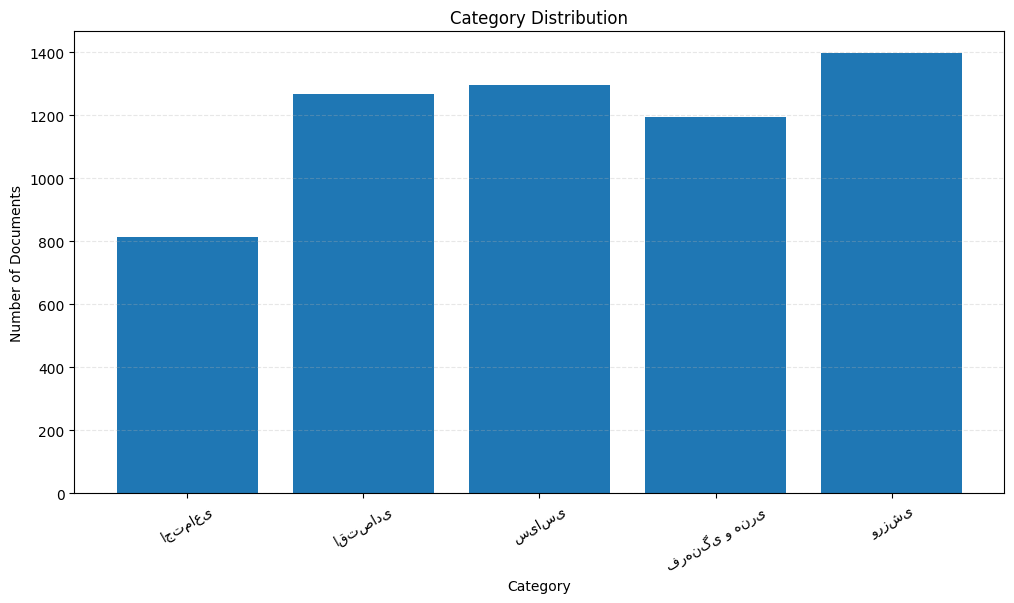

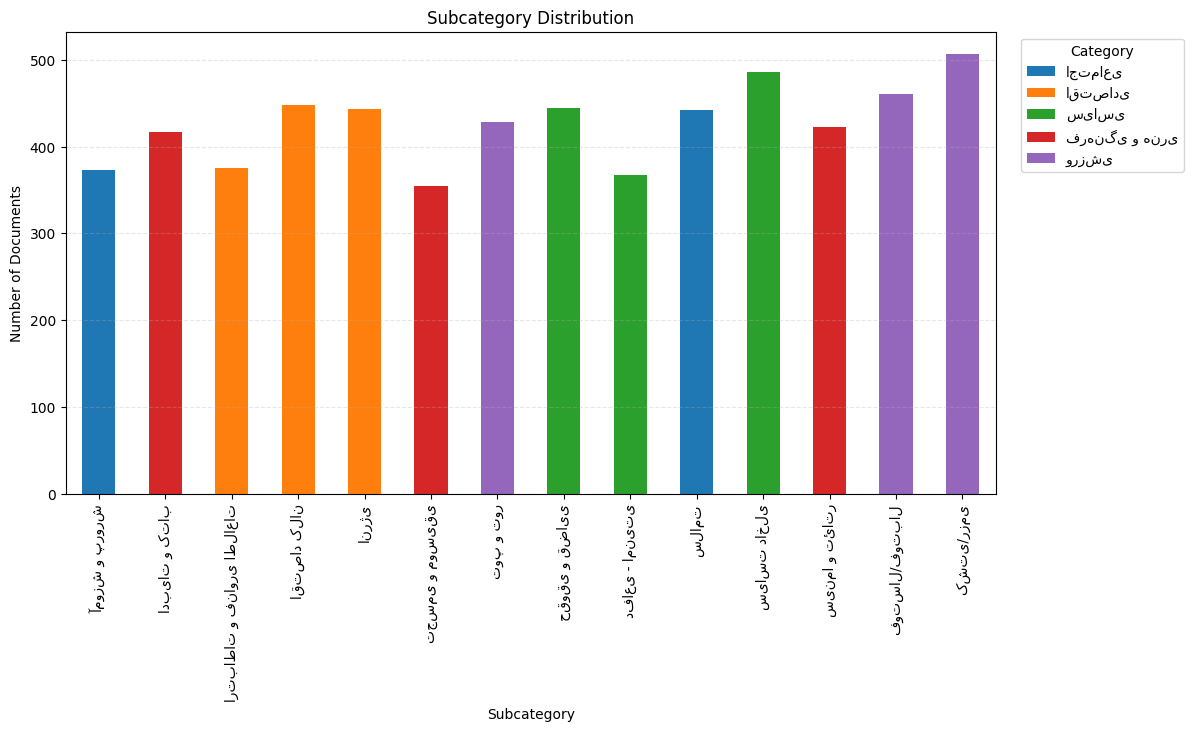

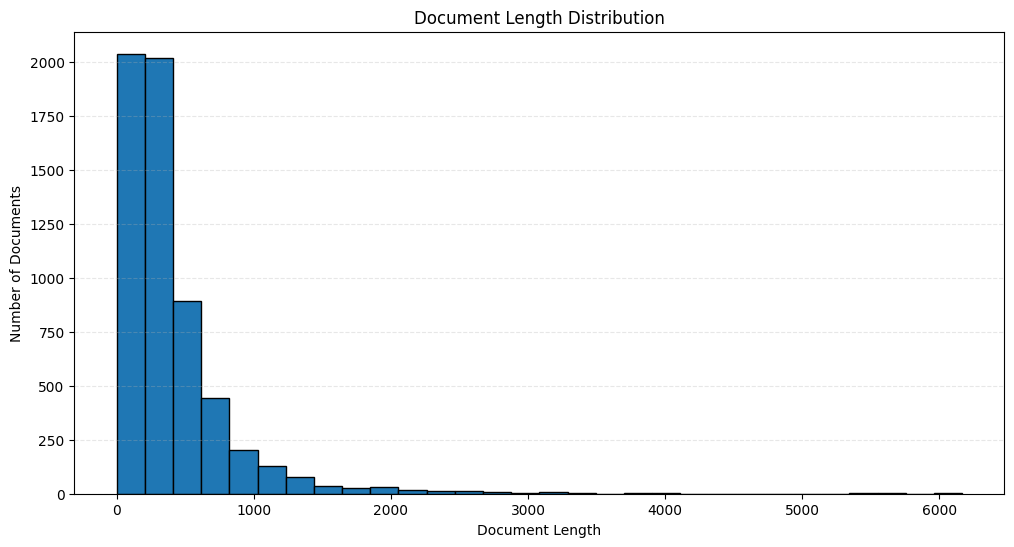

In [9]:
figs = visualize_data.generate_all_figures()
figs_name = figs.keys()
# print(figs.keys())

# visualize_data.save_all_figures(FIGURES_DIR / "data_figs")

# IT'S DONE

In [10]:
# show dataset tabels

for tabel_name in table.keys():
    if tabel_name != 'document_lengths':
        print("**********************")
        print(f"⭕ {tabel_name}")
        print("**********************")
        show_table( tabel_name)
        

**********************
⭕ dataset_statistics
**********************


## Dataset Statistics

Statistic,Value
Number of Documents,5969.000000
Number of Categories,5.000000
Number of Subcategories,14.000000
Average Document Length,409.430000
Vocabulary Size,60929.000000


**********************
⭕ category_statistics
**********************


## Category Statistics

category,Number_of_Subcategories,Number_of_Documents,Percentage,Average_Document_Length
اجتماعی,2,815,13.650000,424.400000
اقتصادی,3,1266,21.210000,421.400000
سیاسی,3,1297,21.730000,451.500000
فرهنگی و هنری,3,1195,20.020000,508.880000
ورزشی,3,1396,23.390000,265.630000


**********************
⭕ subcategory_statistics
**********************


## Subcategory Statistics

category,sub_category,Number_of_Documents,Percentage
اجتماعی,آموزش و پرورش,373,45.770000
اجتماعی,سلامت,442,54.230000
اقتصادی,ارتباطات و فناوری اطلاعات,375,29.620000
اقتصادی,اقتصاد کلان,448,35.390000
اقتصادی,انرژی,443,34.990000
سیاسی,حقوقی و قضایی,444,34.230000
سیاسی,دفاعی - امنیتی,367,28.300000
سیاسی,سیاست داخلی,486,37.470000
فرهنگی و هنری,ادبیات و کتاب,417,34.900000
فرهنگی و هنری,تجسمی و موسیقی,355,29.710000


In [11]:
df.columns

Index(['category', 'sub_category', 'title', 'url', 'content', 'published date',
       'summary', 'news_code'],
      dtype='object')

In [12]:
print("Dataset Shape:")
print(df.shape)

print()

print("Missing Values:")
print(df.isnull().sum())

print()

print("Categories:")

Dataset Shape:
(5969, 8)

Missing Values:
category          0
sub_category      0
title             0
url               0
content           0
published date    0
summary           0
news_code         0
dtype: int64

Categories:


In [13]:
print(f"✅ Train: {len(train_df)} سند")
print(f"✅ Test: {len(test_df)} سند")
print(f"\n📈 توزیع دسته‌ها در Train:")
print(train_df['category'].value_counts())
print(f"\n📈 توزیع دسته‌ها در Test:")
print(test_df['category'].value_counts())

✅ Train: 4775 سند
✅ Test: 1194 سند

📈 توزیع دسته‌ها در Train:
category
ورزشی            1117
سیاسی            1037
اقتصادی          1013
فرهنگی و هنری     956
اجتماعی           652
Name: count, dtype: int64

📈 توزیع دسته‌ها در Test:
category
ورزشی            279
سیاسی            260
اقتصادی          253
فرهنگی و هنری    239
اجتماعی          163
Name: count, dtype: int64


In [14]:
print(f"\n📝 میانگین طول اسناد Train: {np.mean([len(doc.split()) for doc in train_documents]):.0f} کلمه")
print(f"📝 میانگین طول اسناد Test: {np.mean([len(doc.split()) for doc in test_documents]):.0f} کلمه")


📝 میانگین طول اسناد Train: 416 کلمه
📝 میانگین طول اسناد Test: 383 کلمه


In [15]:
# Load Embedding model (ParsBERT)

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME,
    device='cuda'
)

embedding_model.max_seq_length = MAX_LENGTH

print(f"✅ مدل {EMBEDDING_MODEL_NAME} بارگذاری شد.")
print(f"✅ حداکثر طول دنباله: {embedding_model.max_seq_length}")

No sentence-transformers model found with name HooshvareLab/bert-base-parsbert-uncased. Creating a new one with mean pooling.


✅ مدل HooshvareLab/bert-base-parsbert-uncased بارگذاری شد.
✅ حداکثر طول دنباله: 512


In [16]:
# UMAP
umap_model = UMAP(
    n_neighbors=N_NEIGHBORS,
    n_components=N_COMPONENTS,
    min_dist=MIN_DIST,
    metric=UMAP_METRIC,
    random_state=RANDOM_STATE,
    low_memory=False
)


In [17]:
# HDBSCAN
cluster_model = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric='euclidean',
    cluster_selection_method=CLUSTER_SELECTION_METHOD,
    prediction_data=PREDICTION_DATA
)

In [18]:
persian_stopwords = persian_stopwords

vectorizer_model = CountVectorizer(
    stop_words=list(persian_stopwords),
    ngram_range=NGRAM_RANGE,
    min_df=5
)

In [19]:
topic_model = BERTopic(

    embedding_model=embedding_model,

    umap_model=umap_model,

    hdbscan_model=cluster_model,

    vectorizer_model=vectorizer_model,

    language=LANGUAGE,

    calculate_probabilities=CALCULATE_PROBABILITIES,

    verbose=VERBOSE
)

In [21]:
train_embeddings = embedding_model.encode(
    train_documents,
    batch_size=BATCH_SIZE,
    show_progress_bar=True
)

# آموزش مدل
start_time = time.time()
topics, probabilities = topic_model.fit_transform(
    train_documents,
    train_embeddings
)
end_time = time.time()


print(f"Training BERTopic: {end_time:.2f} seconds")


Batches: 100%|██████████| 299/299 [01:47<00:00,  2.79it/s]
2026-08-07 18:01:34,734 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-07 18:01:40,102 - BERTopic - Dimensionality - Completed ✓
2026-08-07 18:01:40,103 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-07 18:01:40,274 - BERTopic - Cluster - Completed ✓
2026-08-07 18:01:40,276 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-07 18:01:42,302 - BERTopic - Representation - Completed ✓


Training BERTopic: 1786113103.02 seconds


In [22]:
topic_info = topic_model.get_topic_info()

In [23]:
hierarchical_topics = topic_model.hierarchical_topics(
    train_documents
)


topic_tree = topic_model.get_topic_tree(
    hierarchical_topics
)

print(topic_tree)

hierarchical_topics.head()

100%|██████████| 7/7 [00:00<00:00, 298.19it/s]

.
├─درصد_برق_افزایش_مصرف_کاهش
│    ├─■──مصرف_دخانیات_بیماری_میتواند_افراد ── Topic: 7
│    └─برق_درصد_نفت_افزایش_شرکت
│         ├─■──درصد_نفت_دلار_افزایش_آمریکا ── Topic: 3
│         └─■──برق_آب_مصرف_انرژی_کشور ── Topic: 6
└─ایران_کشور_تیم_ملی_قرار
     ├─ایران_کشور_اسلامی_جنگ_قرار
     │    ├─■──آموزش_مدارس_پرورش_آموزش پرورش_دانشآموزان ── Topic: 4
     │    └─ایران_کشور_اسلامی_جنگ_قرار
     │         ├─■──کتاب_آثار_جشنواره_موسیقی_نمایش ── Topic: 2
     │         └─کشور_ایران_اسلامی_جنگ_انقلاب
     │              ├─■──کشور_ایران_جنگ_اسلامی_سازمان ── Topic: 0
     │              └─■──اسلامی_ایران_ملت_انقلاب_شهید ── Topic: 5
     └─■──تیم_ایران_بازی_تیم ملی_کیلوگرم ── Topic: 1



,Parent_ID,Parent_Name,Topics,Child_Left_ID,Child_Left_Name,Child_Right_ID,Child_Right_Name,Distance
6,14,ایران_کشور_قرار_تیم_ملی,"[0, 1, 2, 3, 4, 5, 6, 7]",11,درصد_برق_افزایش_مصرف_کاهش,13,ایران_کشور_تیم_ملی_قرار,0.946669
5,13,ایران_کشور_تیم_ملی_قرار,"[0, 1, 2, 4, 5]",12,ایران_کشور_اسلامی_جنگ_قرار,1,تیم_ایران_بازی_تیم ملی_کیلوگرم,0.865721
4,12,ایران_کشور_اسلامی_جنگ_قرار,"[0, 2, 4, 5]",4,آموزش_مدارس_پرورش_آموزش پرورش_دانشآموزان,10,ایران_کشور_اسلامی_جنگ_قرار,0.692239
3,11,درصد_برق_افزایش_مصرف_کاهش,"[3, 6, 7]",7,مصرف_دخانیات_بیماری_میتواند_افراد,9,برق_درصد_نفت_افزایش_شرکت,0.655294
2,10,ایران_کشور_اسلامی_جنگ_قرار,"[0, 2, 5]",2,کتاب_آثار_جشنواره_موسیقی_نمایش,8,کشور_ایران_اسلامی_جنگ_انقلاب,0.622578


In [24]:
test_embeddings = embedding_model.encode(
    test_documents,
    batch_size=BATCH_SIZE,
    show_progress_bar=True
)

start = time.time()

test_topics, test_probabilities = topic_model.transform(
    test_documents,
    test_embeddings
)

end = time.time()


print(f"Transform Test: {end-start:.2f} seconds")

print(
    f"Outliers: "
    f"{(np.array(test_topics)==-1).sum()}"
    f"/"
    f"{len(test_topics)}"
)

Batches: 100%|██████████| 75/75 [00:26<00:00,  2.87it/s]
2026-08-07 18:03:02,820 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-08-07 18:03:12,010 - BERTopic - Dimensionality - Completed ✓
2026-08-07 18:03:12,011 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-08-07 18:03:12,035 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-08-07 18:03:12,106 - BERTopic - Probabilities - Completed ✓
2026-08-07 18:03:12,107 - BERTopic - Cluster - Completed ✓


Transform Test: 9.29 seconds
Outliers: 180/1194


In [25]:
print(f"✅ پیش‌بینی کامل شد!")
print(f"📊 تعداد Outliers در Test: {np.sum(np.array(test_topics) == -1)} ({np.sum(np.array(test_topics) == -1)/len(test_topics)*100:.1f}%)")

✅ پیش‌بینی کامل شد!
📊 تعداد Outliers در Test: 180 (15.1%)


In [26]:
TABLES_DIR.mkdir(parents=True, exist_ok=True)
hierarchical_topics.to_csv(
    TABLES_DIR / "baseline_hierarchical_topics.csv",
    index=False,
    encoding='utf-8-sig'
)

In [27]:
topic_evaluator = TopicEvaluator(
    topic_model=topic_model,
    documents=test_documents,
    topics=test_topics,
    probabilities=test_probabilities,
    dataframe=test_df
)

results = topic_evaluator.evaluate_all()

topic_evaluator.save_results(
    TABLES_DIR / "baseModel_topic_evaluation.csv"
)

Evaluation results saved successfully:
D:\proposal\thiese\code\Persian-Topic-Modeling\results\tables\baseModel_topic_evaluation.csv


In [28]:
show_table("baseModel_topic_evaluation")

## Basemodel Topic Evaluation

Metric,Value
Coherence (using c_v methode),0.683500
Diversity,0.900000
Outlier Ratio (%),15.075400
NMI,0.688600
Purity,0.861900


In [29]:
topic_statistics = TopicStatistics(
    topic_model=topic_model,
    documents=train_documents,
    topics=topics,
    dataframe=train_df,
    probabilities=probabilities
)

topic_statistics.tables.clear()

topic_tables = topic_statistics.generate_all_tables()

# print(topic_tables.keys())

# topic_statistics.save_all_tables(TABLES_DIR)

# IT'S DONE

In [30]:
topic_visualizer = TopicVisualizer(
    topic_model=topic_model,
    statistics = topic_statistics
)

topic_figs = topic_visualizer.generate_all_figs(train_documents , train_embeddings)

# print(topic_figs.keys())

# topic_visualizer.save_all_figures(FIGURES_DIR / "topic_figs")

# ITS'S DONE

In [31]:
# show topics table

for table in topic_tables.keys():
    if table !='topic_information':
        print("**********************")
        print(f"⭕ {table}")
        print("**********************")
        show_table( table)

**********************
⭕ topic_statistics
**********************


## Topic Statistics

Statistic,Value
Number of Topics,8.000000
Average Documents per Topic,539.250000
Largest Topic,1182.000000
Smallest Topic,149.000000
Outlier Documents,461.000000
Outlier Percentage (%),9.650000


**********************
⭕ topic_keywords
**********************


## Topic Keywords

...

## Topic Category Distribution

Topic,category,Count,Percentage
0,اجتماعی,166,14.040000
0,اقتصادی,270,22.840000
0,سیاسی,631,53.380000
0,فرهنگی و هنری,80,6.770000
0,ورزشی,35,2.960000
1,اجتماعی,6,0.580000
1,اقتصادی,1,0.100000
1,سیاسی,5,0.480000
1,فرهنگی و هنری,4,0.380000
1,ورزشی,1023,98.460000


**********************
⭕ topic_subcategory_distribution
**********************


## Topic Subcategory Distribution

Topic,sub_category,Count,Percentage
0,آموزش و پرورش,19,1.610000
0,ادبیات و کتاب,26,2.200000
0,ارتباطات و فناوری اطلاعات,58,4.910000
0,اقتصاد کلان,178,15.060000
0,انرژی,34,2.880000
0,تجسمی و موسیقی,15,1.270000
0,توپ و تور,5,0.420000
0,حقوقی و قضایی,263,22.250000
0,دفاعی - امنیتی,117,9.900000
0,سلامت,147,12.440000


In [33]:
fig_hierarchy = topic_model.visualize_hierarchy(
    hierarchical_topics=hierarchical_topics,
    top_n_topics=20
)

fig_hierarchy.write_html(
    FIGURES_DIR / "topic_figs" / "topic_hierarchy.html"
)

In [34]:
topic_info = topic_model.get_topic_info()

document_info = topic_model.get_document_info(
    documents
)
topic_freq = topic_model.get_topic_freq()

ValueError: All arrays must be of the same length

In [37]:
topic_info.head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,461,-1_قیمتی_تغییرات_درصد_دلار,"[قیمتی, تغییرات, درصد, دلار, قیمت, درصد کاهش, ...",[به گزارش ایسنا بر اساس دادههای سایت سوسوولیو ...
1,0,1182,0_کشور_ایران_جنگ_اسلامی,"[کشور, ایران, جنگ, اسلامی, سازمان, دولت, قانون...",[به گزارش ایسنا به نقل از روابط عمومی سازمان ب...
2,1,1039,1_تیم_ایران_بازی_تیم ملی,"[تیم, ایران, بازی, تیم ملی, کیلوگرم, ملی, مساب...",[به گزارش ایسنا فرناندو کرلینگ پاسور بیستونه س...
3,2,853,2_کتاب_آثار_جشنواره_موسیقی,"[کتاب, آثار, جشنواره, موسیقی, نمایش, اثر, ایرا...",[به گزارش ایسنا همایون شجریان در مراسم رونمایی...
4,3,435,3_درصد_نفت_دلار_افزایش,"[درصد, نفت, دلار, افزایش, آمریکا, شرکت, کاهش, ...",[به گزارش ایسنا به نقل از رویترز روند ابتلا به...
5,4,274,4_آموزش_مدارس_پرورش_آموزش پرورش,"[آموزش, مدارس, پرورش, آموزش پرورش, دانشآموزان,...",[به گزارش ایسنا علیرضا کاظمی در برنامه گفتوگوی...
6,5,206,5_اسلامی_ایران_ملت_انقلاب,"[اسلامی, ایران, ملت, انقلاب, شهید, انقلاب اسلا...",[به گزارش ایسنا متن پیام ذبیحالله خدائیان رئیس...
7,6,176,6_برق_آب_مصرف_انرژی,"[برق, آب, مصرف, انرژی, کشور, صنعت, تولید, نیرو...",[به گزارش ایسنا آیین آغاز برنامههای مدیریت اوج...
8,7,149,7_مصرف_دخانیات_بیماری_میتواند,"[مصرف, دخانیات, بیماری, میتواند, افراد, بهداشت...",[به گزارش ایسنا دکتر علیرضا رییسی در همایش روز...


In [38]:
n_docs = len(documents)
n_topics = len(topic_info) - 1
n_outliers = np.sum(np.array(topics) == -1)

print(f"Number of documents : {n_docs}")
print(f"Number of topics    : {n_topics}")
print(f"Outlier documents   : {n_outliers}")
print(f"Outlier percentage  : {100*n_outliers/n_docs:.2f}%")

Number of documents : 5969
Number of topics    : 8
Outlier documents   : 461
Outlier percentage  : 7.72%


In [39]:
for topic in topic_info.Topic:

    if topic == -1:
        continue

    print("=" * 80)

    print(f"Topic {topic}")

    print(topic_model.get_topic(topic))

Topic 0
[('کشور', 0.03053983912550435), ('ایران', 0.02332272058356737), ('جنگ', 0.018914144055421456), ('اسلامی', 0.016077459302359234), ('سازمان', 0.015574013308068768), ('دولت', 0.015374943445057777), ('قانون', 0.01510877826212678), ('قرار', 0.014989606475285895), ('قضایی', 0.014286552504681665), ('قوه', 0.014030842580851735)]
Topic 1
[('تیم', 0.09405487181642022), ('ایران', 0.053520176393701026), ('بازی', 0.05135617711529084), ('تیم ملی', 0.051100237878470435), ('کیلوگرم', 0.048638629243557975), ('ملی', 0.047174838776008976), ('مسابقات', 0.046443227465621316), ('وزن', 0.04170672427343614), ('قهرمانی', 0.03855351747375643), ('دیدار', 0.03636355135201563)]
Topic 2
[('کتاب', 0.033828590221282484), ('آثار', 0.026320300082594457), ('جشنواره', 0.023081348796030125), ('موسیقی', 0.02266185955592786), ('نمایش', 0.02217321122590715), ('اثر', 0.021958124596855023), ('ایران', 0.020453808365237244), ('کار', 0.0181787156034671), ('فرهنگی', 0.01796901888064416), ('هنری', 0.017804221512562515)]
Top

In [40]:
fig = topic_model.visualize_topics()

fig.show()

In [41]:
fig.write_html(
    FIGURES_DIR / "topic_map.html"
)

In [42]:
fig = topic_model.visualize_barchart(
    top_n_topics=20
)

fig.show()

In [43]:
fig.write_html(
    FIGURES_DIR / "topic_barchart.html"
)

In [45]:
fig.write_html(
    FIGURES_DIR / "topic_hierarchy.html"
)

In [46]:
fig = topic_model.visualize_heatmap()

fig.show()

In [47]:
fig.write_html(
    FIGURES_DIR / "topic_heatmap.html"
)

In [50]:


hierarchical_topics.head()

,Parent_ID,Parent_Name,Topics,Child_Left_ID,Child_Left_Name,Child_Right_ID,Child_Right_Name,Distance
6,14,ایران_کشور_قرار_تیم_ملی,"[0, 1, 2, 3, 4, 5, 6, 7]",11,درصد_برق_افزایش_مصرف_کاهش,13,ایران_کشور_تیم_ملی_قرار,0.946669
5,13,ایران_کشور_تیم_ملی_قرار,"[0, 1, 2, 4, 5]",12,ایران_کشور_اسلامی_جنگ_قرار,1,تیم_ایران_بازی_تیم ملی_کیلوگرم,0.865721
4,12,ایران_کشور_اسلامی_جنگ_قرار,"[0, 2, 4, 5]",4,آموزش_مدارس_پرورش_آموزش پرورش_دانشآموزان,10,ایران_کشور_اسلامی_جنگ_قرار,0.692239
3,11,درصد_برق_افزایش_مصرف_کاهش,"[3, 6, 7]",7,مصرف_دخانیات_بیماری_میتواند_افراد,9,برق_درصد_نفت_افزایش_شرکت,0.655294
2,10,ایران_کشور_اسلامی_جنگ_قرار,"[0, 2, 5]",2,کتاب_آثار_جشنواره_موسیقی_نمایش,8,کشور_ایران_اسلامی_جنگ_انقلاب,0.622578


In [51]:
hierarchical_topics.to_csv(
    FIGURES_DIR / "hierarchical_topics.csv",
    index=False,
    encoding="utf-8-sig"
)

In [52]:
fig = topic_model.visualize_hierarchy(
    hierarchical_topics=hierarchical_topics
)

fig.show()

In [53]:
fig.write_html(
    FIGURES_DIR / "topic_tree.html"
)

In [54]:
topic_labels = {}

for topic in topic_info.Topic:

    if topic == -1:
        continue

    words = topic_model.get_topic(topic)

    label = " | ".join(
        [word for word, _ in words[:3]]
    )

    topic_labels[topic] = label

In [55]:
topic_labels

{0: 'کشور | ایران | جنگ',
 1: 'تیم | ایران | بازی',
 2: 'کتاب | آثار | جشنواره',
 3: 'درصد | نفت | دلار',
 4: 'آموزش | مدارس | پرورش',
 5: 'اسلامی | ایران | ملت',
 6: 'برق | آب | مصرف',
 7: 'مصرف | دخانیات | بیماری'}

In [ ]:
labeler = TopicLabelGenerator(topic_model)

df = pd.read_csv(
    TABLES_DIR / "topic_keywords.csv"
)

for topic_id, group in df.groupby("Topic"):
    
    topic_words = group["Keywords"].tolist()

    label = labeler.generate_label(topic_words)

    print(topic_id, label)


ResponseError: model 'llama3.1:8b' not found (status code: 404)